In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from physiology_utilities import computeFlows, dictToVec, vecToDict, dictToGraph, graphToDict, implementGraphStruct, dictOfFxns
from dynamics_fxns import odemasterfxn
import cvxpy as cp


{'pulm': {'pulm': 0.0, 'systemic': 1.0}, 'systemic': {'pulm': 1.0, 'systemic': 0.0}}
[[0.         8.99999999]
 [1.         0.        ]]


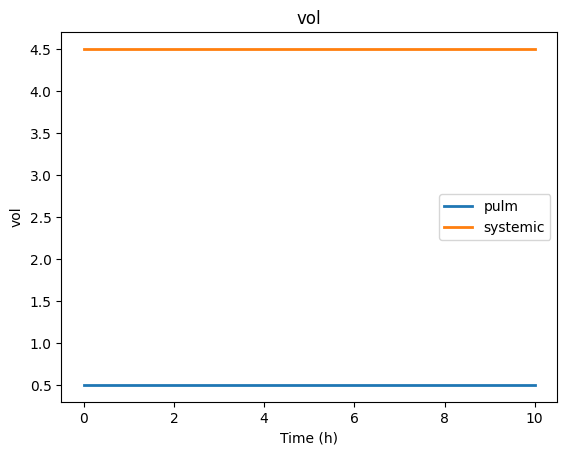

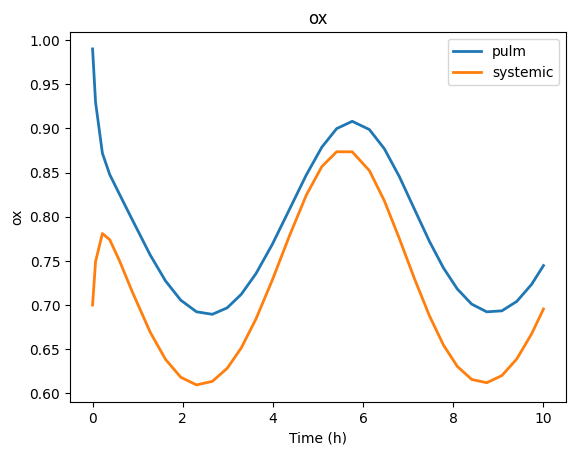

In [6]:
## Initial states and constants
speciesList = ['vol','ox','hgb']
compartmentList = ['pulm','systemic']

# Initialize state for each species
stateDict = vecToDict(0,speciesList,compartmentList)

# Homeostatic distribution of species (flows will be back-computed from this)
stateDict['vol']['systemic'] = 4.5
stateDict['vol']['pulm'] = 0.5

# Starting to build a special library of binding functions...
# First we need a function that defines 'is carried by'
carrierDict = {}
carrierDict['vol'] = []
carrierDict['hgb'] = 'vol'
carrierDict['ox'] = 'hgb'

stateDict['ox']['systemic'] = 0.7
stateDict['ox']['pulm'] = 0.99

stateDict['hgb']['systemic'] = 1.0
stateDict['hgb']['pulm'] = 1.0

# Build a vector of the homeostatic levels for numerical computations 
V = []
for cpt in compartmentList: 
    V.append(stateDict[speciesList[0]][cpt])
V = np.array(V)

# Initialize data structure over which we will compute rates
structDef_In = {}; structDef_Out = {}
structDef_Out['systemic']=['pulm']
structDef_Out['pulm']=['systemic']

flowK = graphToDict(0,compartmentList)
flowK = implementGraphStruct(flowK,compartmentList,structDef_Out,structDef_In)
print(flowK)
# Compute the rates from steay-state data (up to fluxes)
# NOTE: fluxes ARE important for perturbation response! 
# TODO: thread through functionalization k(t,x) everywhere
flowK = computeFlows(dictToGraph(flowK,compartmentList),V)
print(flowK)

flowK = graphToDict(flowK,compartmentList)


initialStateVec = dictToVec(stateDict,speciesList,compartmentList)

# Time span (h)
t_start = 0.0
t_end = 10.0
t_span = (t_start, t_end)

# initialized growth rates
growth = vecToDict(0,speciesList,compartmentList)

# initialize external inflows/outflows as functions
externalK = dictOfFxns(vecToDict(0,speciesList,compartmentList))
# systemic load
externalK['ox']['systemic'] = lambda t, x: x['hgb']['systemic']*(.40**2)-.4*(np.sin(t)+1.5)*x['ox']['systemic'] 
# Feedback relationship implemented in pulm 
externalK['ox']['pulm'] = lambda t, x: x['hgb']['pulm']*(.99**2)-.9*x['ox']['pulm'] 


### ODE solver call (Runge-Kutta)
solution = solve_ivp(odemasterfxn,[t_start,t_end],initialStateVec,method='RK45',args = (speciesList,compartmentList,flowK,externalK,growth,carrierDict))

### Plotting
tsPlot = vecToDict(solution.y,speciesList,compartmentList)
plotSpeciesList = ['vol','ox']
for species in plotSpeciesList:
    plt.figure()
    for key in tsPlot[species].keys():
        plt.plot(solution.t, tsPlot[species][key], linewidth=2,label=key)
    plt.ylabel(species)
    plt.xlabel('Time (h)')
    plt.title(species)
    plt.legend()

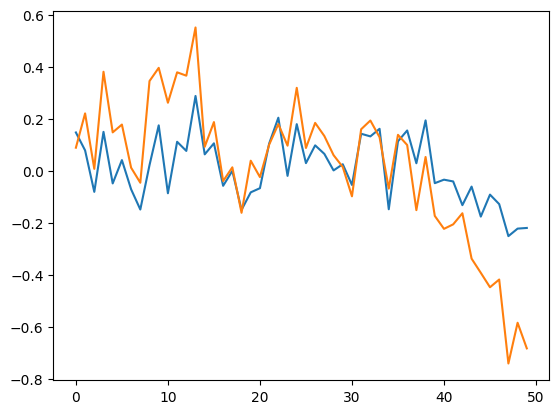

In [87]:
allcol = ["#185FA5","#D85A30","#1D9E75","#BA7517","#888780",'red']

def simulate(a,k,T):
    x=np.zeros((2,T))
    
    wlevel = 0.1
    vlevel = 0.1
    a01 = a
    a10 =.2
    x[0,0] = np.random.randn()*wlevel
    x[1,0] = np.random.randn()*wlevel
    for tt in range(1,T):
        x[0,tt] = (1-a01)*x[0,tt-1]+a10*x[1,tt-1]-k*(np.sum(x[:,tt-1])+np.random.randn()*wlevel)
        x[1,tt] = (1-a10)*x[1,tt-1]+a01*x[0,tt-1]+np.random.randn()*wlevel
    return x + np.random.randn(T)*vlevel
nIter = 50
T = 50
plt.plot(x[0,:])
plt.plot(x[1,:])

sampleThese =np.linspace(2,T,T-2+1).astype(int)
acl = 0.8
alld = [0.0,1.0]
alla = [acl,acl]
cx=np.zeros((nIter,len(sampleThese),len(alld)))
for ii in range(nIter):
    for dd in range(len(alld)):
        d = alld[dd]
        true_a = alla[dd]
        true_k = 0.0
        x = simulate(true_a,true_k,T)
        arange = 1e6
        for nn in range(len(sampleThese)):
            N = sampleThese[nn]
            A = cp.Variable((2,2))
            avar2 = cp.Variable()
            avar1 = cp.Variable()
            if d==1:    
                constraints = [avar1==avar2]
            else:
                constraints = []
            constraints += [A[0,0]==1.0-avar1]
            constraints += [A[1,0]==avar2]
            constraints += [A[0,1]==0.2]
            constraints += [A[1,1]==1.0-.2]
            cost = cp.sum_squares(A @ x[:,1:N]-x[:,:N-1])/N
            prob = cp.Problem(cp.Minimize(cost),constraints)
            prob.solve(solver=cp.SCS, eps=1e-6)
            if avar1.value:
                cx[ii,nn,dd] = np.abs(avar1.value-acl)+np.abs(avar2.value-acl)
            else:
                cx[ii,nn,dd] = np.nan

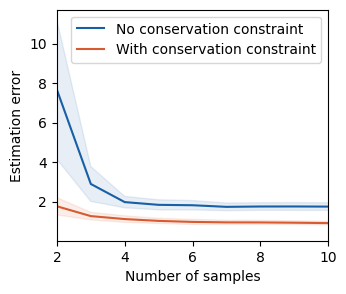

In [90]:

plt.figure(figsize=(3.5,3))

for dd in range(len(alld)):
    se = np.nanstd(cx[:,:,dd],axis=0)
    se = np.array([x/np.sqrt(nIter) for x,y in zip(se,sampleThese)])
    plt.fill_between(sampleThese,np.squeeze(np.nanmean(cx[:,:,dd],axis=0)) - 1.96*se, np.squeeze(np.nanmean(cx[:,:,dd],axis=0)) + 1.96*se, color=allcol[dd],alpha=0.1,label='_')
for dd in range(len(alld)):
    
    lbl = 'a = ' + str(alla[dd]) + ', $\Delta$ = ' + str(alld[dd]) + ', SetVol = ' + str(polytopeVol[dd])
    if alld[dd] == 0:
        lbl = 'No conservation constraint'
    else:
        lbl = 'With conservation constraint'
    # lbl = 'a = ' + str(alla[dd])

    plt.plot(sampleThese,np.squeeze(np.nanmean(cx[:,:,dd],axis=0)),color=allcol[dd],label=lbl)

sigtest = np.zeros((np.shape(cx)[1]))
# for tt in range(np.shape(cx)[1]):
#     p = (stats.ttest_ind(cx[:,tt,0],cx[:,tt,1]))
#     if p.pvalue < .05:
#         sigtest[tt] = 1
#     else:
#         sigtest[tt] = np.nan

# plt.plot(sampleThese,sigtest* .7,'k--',linewidth = .5,label = 'p < .05') 


# plt.ylim((0.2,0.75))
plt.xlim((2,10))
plt.xlabel('Number of samples')
plt.ylabel('Estimation error')

plt.legend()

